# Path B - Gold vs CPI and US Dollar Index (Continues from PathA)

PathA (gold only) is preserved at Visual-Gold-Explorer-PathA.ipynb. This file reuses its loaders and adds macro overlays. If you’ve seen PathA, skip to Piece 8.

Dataset is collected from `Dataset/gold-price.csv`, `Dataset/CPIAUCSL.csv`, and `Dataset/US Dollar Index Historical Data.csv`.

## Piece 1 — Loading the Helpers and Libraries
Install helpers once, then we see the data, just like unpacking puzzle pieces.

In [44]:
# Run this once. If it says 'already satisfied', we're good to go.
# We use plotly = interactive lines, ipywidgets = sliders
%pip install -q pandas plotly ipywidgets openpyxl
print("Setup done — charts are now zoomable Wand draggable")

Note: you may need to restart the kernel to use updated packages.
Setup done — charts are now zoomable Wand draggable


In [45]:
import numpy as np
# Compatibility patch: some libraries still call np.matrix which was removed in NumPy 2.0
# This keeps the notebook working on both NumPy 1.x and 2.x without downgrading
if not hasattr(np, 'matrix'):
    np.matrix = np.asmatrix  # type: ignore[attr-defined]
    print("patched np.matrix for NumPy 2.x compatibility")

import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from ipywidgets import interact, IntSlider, IntRangeSlider
import pathlib

# Library check
print("Libraries ready:", pd.__version__)

Libraries ready: 3.0.3


## Piece 2 — Load and Feel the Data (Gold Price First)
We load the `gold-price.csv`. `US Dollar Index Historical Data.csv`, and `CPIAUCSL.csv` before opening the monthly album of `gold-price.csv`.

In [46]:
# List the 3 datasets we use for Path B -- gold only (PathA) + CPI + Dollar
# This loop reads them all so we don't repeat pd.read_csv 3 times
import pathlib as _pl

dataset_list = [
    ("gold", "gold-price.csv", ["date"], "date"),
    ("cpi", "CPIAUCSL.csv", ["observation_date"], "observation_date"),
    ("dxy", "US Dollar Index Historical Data.csv", ["Date"], "Date"),
]

# Resolve base: try relative Dataset/ first, fallback to absolute
base_rel = _pl.Path("Dataset")
base_abs = _pl.Path(r"D:\Daniel\Data Science Project\Visual-Gold-Explorer-Why-Gold-Moves-in-Crisis-with-Honest-Baseline-\Dataset")

dfs = {}
for name, fname, parse_cols, sort_col in dataset_list:
    csv_path = base_rel / fname
    if not csv_path.exists():
        csv_path = base_abs / fname
    # Read with parse_dates where possible; DXY uses MM/DD/YYYY which pandas handles, but we coerce if needed
    df = pd.read_csv(csv_path, parse_dates=parse_cols)
    # Fallback for DXY if Date stayed as string
    if name == "dxy" and df[sort_col].dtype == object:
        df[sort_col] = pd.to_datetime(df[sort_col], format="%m/%d/%Y", errors="coerce")
    df = df.sort_values(sort_col)
    dfs[name] = df
    print(f"{name}: {len(df)} rows | {sort_col} {df[sort_col].min()} -> {df[sort_col].max()} | file: {csv_path.name}")

# Unpack for later cells (keeps old variable names so rest of notebook still works)
gold = dfs["gold"]


print(f"\nRows: {len(gold)} | From {gold['date'].min().date()} to {gold['date'].max().date()}")
print(gold.head(3).to_string(index=False))
print("---")
print(gold.tail(3).to_string(index=False))
print("\nScroll the output. 1960 = $35 flat (fixed price), 2026 = ~$4000. That's the story.")

gold: 799 rows | date 1960-01-01 00:00:00 -> 2026-07-01 00:00:00 | file: gold-price.csv
cpi: 955 rows | observation_date 1947-01-01 00:00:00 -> 2026-07-01 00:00:00 | file: CPIAUCSL.csv
dxy: 12056 rows | Date 1979-12-26 00:00:00 -> 2026-09-02 00:00:00 | file: US Dollar Index Historical Data.csv

Rows: 799 | From 1960-01-01 to 2026-07-01
      date  gold_price_usd
1960-01-01              35
1960-02-01              35
1960-03-01              35
---
      date  gold_price_usd
2026-05-01            4587
2026-06-01            4228
2026-07-01            4073

Scroll the output. 1960 = $35 flat (fixed price), 2026 = ~$4000. That's the story.


In [47]:
# Missing value check for the gold price dataset
print("Missing values:", gold["gold_price_usd"].isna().sum())
print("Example check — Sep 2000:")
print(gold[gold["date"]=="2000-09-01"])

Missing values: 0
Example check — Sep 2000:
          date  gold_price_usd
488 2000-09-01             274


## Piece 3 — Quick Recap from PathA

This section recaps the shape of the gold price data, the crises bands, and the same moving average logic as PathA.

In [48]:
crises = [
    ("2007-12-01", "2009-06-01", "2008 Financial Crisis"),
    ("2020-02-01", "2020-04-01", "Covid"),
    ("2022-01-01", "2022-12-01", "2022 Inflation Shock"),
]

print(f"Recap: gold {len(gold)} months (1960-2026), crises {len(crises)} bands, same MA logic as PathA")

Recap: gold 799 months (1960-2026), crises 3 bands, same MA logic as PathA


## Piece 4 — Two Sliders: Year Range & Moving Average

Sliders are movable to trigger the line reaction inside the chart.

---
**Slider 1: Year range** (like cropping a photo)

**Slider 2: Moving average (MA)** (like smoothing wrinkles. MA=3 = wiggly, MA=12 = smooth yearly trend (since data is monthly, 12 = 1-year average))

In [49]:
# Prepare a helper column: moving average
# For monthly data, window=12 means 12-month average
def plot_with_sliders(year_start=2000, year_end=2026, ma_window=12, show=True):
    # plot_with_sliders' 3 params are failsafe defaults when interact is not present
    # show=True -> display in Jupyter (for Piece 5), show=False -> silent return for HTML export (for final cell)
    subset = gold[(gold["date"].dt.year >= year_start) & (gold["date"].dt.year <= year_end)].copy()
    subset["MA"] = subset["gold_price_usd"].rolling(window=ma_window, min_periods=1).mean()
    
    goldfig = go.Figure()
    goldfig.add_trace(go.Scatter(x=subset["date"], y=subset["gold_price_usd"], mode="lines", name="Monthly Price",
                                 line=dict(width=1.5, color="gray"), opacity=0.7))
    goldfig.add_trace(go.Scatter(x=subset["date"], y=subset["MA"], mode="lines", name=f"{ma_window}-Month Avg",
                                 line=dict(width=3, color="#d4a017")))
    # Keep crisis shading only if in range
    for start, end, label in crises:
        if str(year_start) <= start <= str(year_end) or str(year_start) <= end <= str(year_end):
            goldfig.add_vrect(x0=start, x1=end, fillcolor="gray", opacity=0.15, line_width=0)
    goldfig.update_layout(title=f"Gold {year_start}-{year_end} | MA={ma_window} months -- Move Sliders Below",
                          xaxis_title="Year", yaxis_title="USD/oz", height=420, width=800)
    if show:
        goldfig.show()
        return None
    else:
        return goldfig

print("Sliders ready. Move them below -- watch the gold line smooth or crop.")


Sliders ready. Move them below -- watch the gold line smooth or crop.


In [50]:
# Three sliders for the year range and the moving average window
from ipywidgets import fixed
interact(plot_with_sliders,
         year_start=IntSlider(value=2000, min=1960, max=2024, step=1, description="Start Year"),
         year_end=IntSlider(value=2026, min=1961, max=2026, step=1, description="End Year"),
         ma_window=IntSlider(value=12, min=1, max=36, step=1, description="MA Months"),
         show=fixed(True));

interactive(children=(IntSlider(value=2000, description='Start Year', max=2024, min=1960), IntSlider(value=202…

## Piece 5 — Load and Feel the Consumer Price Index and USD Index
We open the monthly album of `US Dollar Index Historical Data.csv` and `CPIAUCSL.csv`.

In [51]:
cpi = dfs["cpi"]
dxy = dfs["dxy"]

print(f"\nCPI Rows: {len(cpi)} | From {cpi['observation_date'].min().date()} to {cpi['observation_date'].max().date()}")

print(cpi.head(3).to_string(index=False))
print("---")
print(cpi.tail(3).to_string(index=False))

print("===========================")

print(f"DXY Rows: {len(dxy)} | From {dxy['Date'].min().date()} to {dxy['Date'].max().date()}")

print(dxy.head(3).to_string(index=False))
print("---")
print(dxy.tail(3).to_string(index=False))


CPI Rows: 955 | From 1947-01-01 to 2026-07-01
observation_date  CPIAUCSL
      1947-01-01     21.48
      1947-02-01     21.62
      1947-03-01     22.00
---
observation_date  CPIAUCSL
      2026-05-01   333.979
      2026-06-01   332.568
      2026-07-01   332.813
DXY Rows: 12056 | From 1979-12-26 to 2026-09-02
      Date  Price  Open  High   Low  Vol. Change %
1979-12-26  85.99 85.99 85.99 85.99   NaN   -0.21%
1979-12-27  85.51 85.51 85.51 85.51   NaN   -0.56%
1979-12-28  85.81 85.81 85.81 85.81   NaN    0.35%
---
      Date  Price  Open  High   Low  Vol. Change %
2026-08-31  99.43 99.70 99.71 99.39   NaN   -0.27%
2026-09-01  99.68 99.42 99.72 99.35   NaN    0.25%
2026-09-02  99.76 99.77 99.81 99.67   NaN    0.09%


In [52]:
# Missing values check for CPI and DXY datasets
print(f"CPI Missing Values: {cpi['CPIAUCSL'].isna().sum()}")
print(f"DXY Missing Values: {dxy['Price'].isna().sum()}")

CPI Missing Values: 1
DXY Missing Values: 0


In [53]:
# Handle missing values
cpi["CPIAUCSL"] = cpi["CPIAUCSL"].interpolate(method="linear")
print(f"CPI missing after interpolation: {cpi['CPIAUCSL'].isna().sum()}")

dxy = dxy[["Date", "Price"]].copy()
dxy["Price"] = pd.to_numeric(dxy["Price"], errors="coerce")

CPI missing after interpolation: 0


## Piece 6 — Merge Gold Price, Consumer Price Index, and USD Index Datasets
- We resample USD Index (DXY) to monthly frequency
- Merge Gold Price, Consumer Price Index, and USD Index Datasets
- Verify the oldest/latest date, and rows/missing values count
- **(Optional)** Save the merged datasets to a CSV file for last step verification

In [54]:
# Resample DXY to monthly frequency, taking the last available value for each month
dxy_monthly = dxy.set_index('Date').resample('MS').last()

# Merge the datasets on their respective date columns
merged = gold.merge(cpi, left_on="date", right_on="observation_date", how="inner").merge(dxy_monthly, left_on="date", right_on="Date", how="inner")

# Check the merged dataset
print(f"Merged: {len(merged)} months | {merged['date'].min().date()} -> {merged['date'].max().date()}")
print(merged.head(3).to_string(index=False))
print("------------------------------------------------------------")
print(merged.tail(3).to_string(index=False))
print("------------------------------------------------------------")
print(f"Rows count: {merged.count()}")
print("-------------------------------------------")
print(f"Missing values count: {merged.isna().sum()}")

# Save the merged dataset to a CSV file for last step verification and further analysis
# merged_to_csv = merged.to_csv(
#    "testing_data.csv",
#    index=False
# )

Merged: 560 months | 1979-12-01 -> 2026-07-01
      date  gold_price_usd observation_date  CPIAUCSL  Price
1979-12-01             455       1979-12-01      76.9  85.82
1980-01-01             675       1980-01-01      78.0  86.14
1980-02-01             665       1980-02-01      79.0  87.65
------------------------------------------------------------
      date  gold_price_usd observation_date  CPIAUCSL  Price
2026-05-01            4587       2026-05-01   333.979  98.91
2026-06-01            4228       2026-06-01   332.568 101.19
2026-07-01            4073       2026-07-01   332.813  99.91
------------------------------------------------------------
Rows count: date                560
gold_price_usd      560
observation_date    560
CPIAUCSL            560
Price               560
dtype: int64
-------------------------------------------
Missing values count: date                0
gold_price_usd      0
observation_date    0
CPIAUCSL            0
Price               0
dtype: int64


## Piece 7 — Plotting the Gold Price, Consumer Price Index, and USD Index

In [55]:
base = merged.iloc[0]
merged["gold_idx"] = merged["gold_price_usd"] / base["gold_price_usd"] * 100
merged["cpi_idx"] = merged["CPIAUCSL"] / base["CPIAUCSL"] * 100
merged["dxy_idx"] = merged["Price"] / base["Price"] * 100

#### Fig1 — Merged Static 3-Line (Normalized to Index 100) with Crisis Bands
All three start at 100 on Dec 1979 (first `merged` row). Like a race starting line — who grows fastest?
Gold vs CPI vs Dollar on one ruler, no bands, no MA. Just growth.
The chart is featured with gray bands for 2008, Covid 2020, 2022 Inflation Shock.


In [56]:
# Fig1 PathB — 3-line + crisis shading
fig_merged_bands = go.Figure()
fig_merged_bands.add_trace(go.Scatter(x=merged['date'], y=merged['gold_idx'], mode='lines', name='Gold (Idx 100)', line=dict(width=2.5, color='#d4a017')))
fig_merged_bands.add_trace(go.Scatter(x=merged['date'], y=merged['cpi_idx'], mode='lines', name='CPI (Idx 100)', line=dict(width=1.8, color='#636efa')))
fig_merged_bands.add_trace(go.Scatter(x=merged['date'], y=merged['dxy_idx'], mode='lines', name='DXY (Idx 100)', line=dict(width=1.8, color='#EF553B')))
for start, end, label in crises:
    fig_merged_bands.add_vrect(x0=start, x1=end, fillcolor='gray', opacity=0.15, line_width=0, annotation_text=label, annotation_position='top left')
fig_merged_bands.update_layout(title='PathB Fig1 — Same 3 Lines with Crisis Bands (2008, Covid, 2022)', xaxis_range=[merged['date'].min(), merged['date'].max()], xaxis_title='Year', yaxis_title='Index 100 = Dec 1979', height=440, width=1200)
fig_merged_bands.show()
print("Fig1: See 2008: DXY spikes while gold dips first, CPI keeps rising slowly.")


Fig1: See 2008: DXY spikes while gold dips first, CPI keeps rising slowly.


#### Fig2 — 3 Lines with MA (Gold Only, Single Slider)
Each slider smooths one line individually + year crops the chart:
- **Year Start / End** = crop photo (1979-2026)
- **Gold MA** = smooth Gold wrinkles (MA 12 = 1-year avg)
- **CPI MA** = smooth Inflation wrinkles
- **DXY MA** = smooth Dollar wrinkles

In [57]:
# Fig2 PathB — 3 lines + 3 individual MAs + Year slider
def plot_merged_with_ma(year_start=1979, year_end=2026, gold_ma=12, cpi_ma=12, dxy_ma=12, show=True):
    # Crop by year first, then smooth each idx separately
    tmp = merged[(merged["date"].dt.year >= year_start) & (merged["date"].dt.year <= year_end)].copy()
    tmp["gold_ma_idx"] = tmp["gold_idx"].rolling(window=gold_ma, min_periods=1).mean()
    tmp["cpi_ma_idx"] = tmp["cpi_idx"].rolling(window=cpi_ma, min_periods=1).mean()
    tmp["dxy_ma_idx"] = tmp["dxy_idx"].rolling(window=dxy_ma, min_periods=1).mean()
    fig = go.Figure()
    # Raw faint lines (like wrinkles)
    fig.add_trace(go.Scatter(x=tmp["date"], y=tmp["gold_idx"], mode="lines", name="Gold raw (Idx)", line=dict(width=1, color="gray"), opacity=0.35))
    fig.add_trace(go.Scatter(x=tmp["date"], y=tmp["cpi_idx"], mode="lines", name="CPI raw (Idx)", line=dict(width=1, color="gray"), opacity=0.35))
    fig.add_trace(go.Scatter(x=tmp["date"], y=tmp["dxy_idx"], mode="lines", name="DXY raw (Idx)", line=dict(width=1, color="gray"), opacity=0.35))
    # MA bold lines (smooth)
    fig.add_trace(go.Scatter(x=tmp["date"], y=tmp["gold_ma_idx"], mode="lines", name=f"Gold MA{gold_ma} (Idx)", line=dict(width=3, color="#d4a017")))
    fig.add_trace(go.Scatter(x=tmp["date"], y=tmp["cpi_ma_idx"], mode="lines", name=f"CPI MA{cpi_ma} (Idx)", line=dict(width=2.5, color="#636efa")))
    fig.add_trace(go.Scatter(x=tmp["date"], y=tmp["dxy_ma_idx"], mode="lines", name=f"DXY MA{dxy_ma} (Idx)", line=dict(width=2.5, color="#EF553B")))
    for start, end, label in crises:
        fig.add_vrect(x0=start, x1=end, fillcolor="gray", opacity=0.12, line_width=0)
    fig.update_layout(title=f"PathB Fig2 — {year_start}-{year_end} | Gold MA{gold_ma} CPI MA{cpi_ma} DXY MA{dxy_ma}", xaxis_title="Year", yaxis_title="Index 100 = Dec 1979", height=460, width=900)
    if show:
        fig.show()
        return None
    else:
        return fig
print("Slider ready for Fig2 — 3 MAs + Year: drag each to smooth one line")


Slider ready for Fig2 — 3 MAs + Year: drag each to smooth one line


In [ ]:
# 5 sliders for Fig2 — Year range + 3 individual MAs
from ipywidgets import fixed
interact(plot_merged_with_ma,
         year_start=IntSlider(value=1979, min=1979, max=2024, step=1, description="Start Year"),
         year_end=IntSlider(value=2026, min=1980, max=2026, step=1, description="End Year"),
         gold_ma=IntSlider(value=12, min=1, max=36, step=1, description="Gold MA"),
         cpi_ma=IntSlider(value=12, min=1, max=36, step=1, description="CPI MA"),
         dxy_ma=IntSlider(value=12, min=1, max=36, step=1, description="DXY MA"),
         show=fixed(True));


interactive(children=(IntSlider(value=1979, description='Start Year', max=2024, min=1979), IntSlider(value=202…

#### Fig3 (4th Chart) — Nixon Period: Gold + CPI 1960-1979 (Large Separate Chart)
DXY didn't exist until Dec 1979, so this shows only Gold and CPI from the flat-price era (1960-1979). Gold flat at $35, CPI rose slowly. Nixon ended convertibility in Aug 1971 because dollars were printed for Vietnam and gold reserves drained.

In [59]:
# Fig3 — Nixon large separate chart: Gold + CPI 1960-1979 (no DXY)
# Use original gold and CPI (not merged) for 1960-1979
nixon_gold = gold[(gold['date'] >= '1960-01-01') & (gold['date'] < '1979-12-01')].copy()
nixon_cpi = cpi[(cpi['observation_date'] >= '1960-01-01') & (cpi['observation_date'] < '1979-12-01')].copy()
# Normalize both to 100 on Jan 1960 for fair comparison
base_gold_1960 = nixon_gold.iloc[0]['gold_price_usd']
base_cpi_1960 = nixon_cpi.iloc[0]['CPIAUCSL']
nixon_gold['idx'] = nixon_gold['gold_price_usd'] / base_gold_1960 * 100
nixon_cpi['idx'] = nixon_cpi['CPIAUCSL'] / base_cpi_1960 * 100
fig_nixon = go.Figure()
fig_nixon.add_trace(go.Scatter(x=nixon_gold['date'], y=nixon_gold['idx'], mode='lines', name='Gold (Idx 100 = Jan 1960)', line=dict(width=2.5, color='#d4a017')))
fig_nixon.add_trace(go.Scatter(x=nixon_cpi['observation_date'], y=nixon_cpi['idx'], mode='lines', name='CPI (Idx 100 = Jan 1960)', line=dict(width=2, color='#636efa')))
# Mark Nixon shock Aug 1971
fig_nixon.add_vline(x='1971-08-15', line_width=2, line_dash='dash', line_color='red', annotation_text='Nixon Shock Aug 1971', annotation_position='top')
fig_nixon.update_layout(title='PathB Fig3 — Nixon Era 1960-1979: Gold Flat vs CPI Rising (DXY Not Yet Born)', xaxis_title='Year', yaxis_title='Index 100 = Jan 1960', height=440, width=900, margin=dict(l=60,r=20,t=50,b=40))
fig_nixon.show()
print(f"Nixon base Jan 1960: Gold ${base_gold_1960:.0f}=100, CPI {base_cpi_1960:.1f}=100")
print("See: Gold flat at 100 until 1971, CPI climbs to ~260 by 1979. DXY not shown — started Dec 1979.")

Nixon base Jan 1960: Gold $35=100, CPI 29.4=100
See: Gold flat at 100 until 1971, CPI climbs to ~260 by 1979. DXY not shown — started Dec 1979.


## Piece 8 — Correlation Matrix & Heatmap (Pearson)
Static = the whole merged data from 1979-2026 (560 months → 1 number per pair).

**Red = together, blue = opposite, pale = weak. Number = strength.**

**What we see:**
- Gold vs CPI **0.83** (dark red) - strongly together long-run, both trend up.
- Gold vs DXY **-0.14** (pale blue) - weakly opposite.
- CPI vs DXY **-0.28** (light blue) - weakly opposite.

Correlation matrix: 
          gold_idx   cpi_idx   dxy_idx
gold_idx  1.000000  0.827717 -0.144023
cpi_idx   0.827717  1.000000 -0.277835
dxy_idx  -0.144023 -0.277835  1.000000


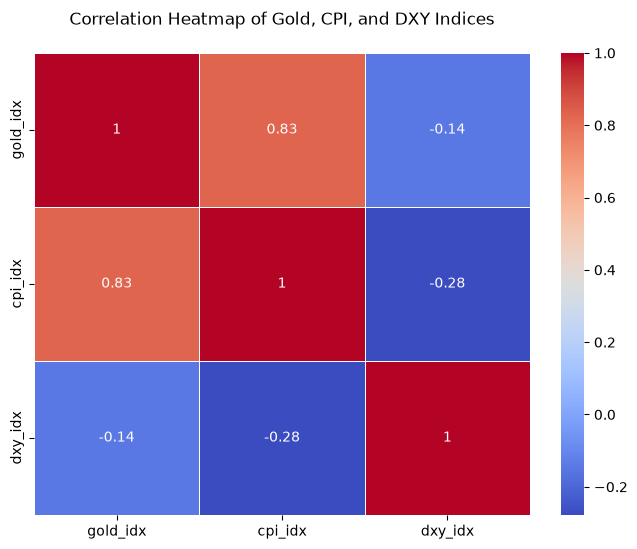

Spearman gives same direction: Gold-CPI 0.74, Gold-DXY -0.30 — so the spike in 2024-2026 isn't driving the story.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap of the three indices
merge_heatmap = merged[['gold_idx', 'cpi_idx', 'dxy_idx']].corr()

# Display the correlation matrix
print(f"Correlation matrix: \n{merge_heatmap}")

plt.figure(figsize=(8, 6))

sns.heatmap(
    merge_heatmap,
    annot=True,
    cmap = 'coolwarm',
    xticklabels=merge_heatmap.columns,
    yticklabels=merge_heatmap.columns,
    linewidths=0.5
)

# Display the colourful correlation heatmap
plt.title('Correlation Heatmap of Gold, CPI, and DXY Indices\n')
plt.show()
print("Spearman gives same direction: Gold-CPI 0.74, Gold-DXY -0.30, so the spike in 2024-2026 isn't driving the story.")

## Piece 9 — Honest Baseline Forecast (Gold Only, Same as PathA)
We test the simplest prediction: *next month = this month*. If even this is off by hundreds, we prove gold is hard to predict.
CPI and DXY are not forecasted here because they live on different rulers ($4000 vs $330 vs $100), so plotting together makes CPI/DXY look flat. This piece is gold-only.


In [99]:
# Honest baseline — Gold only
df = merged.copy()
df["naive_next"] = df["gold_price_usd"].shift(1)  # next month = this month
df["ma3_next"] = df["gold_price_usd"].rolling(3).mean().shift(1)  # avg last 3 months
df["ma12_next"] = df["gold_price_usd"].rolling(12).mean().shift(1)  # avg last 12 months

# Test on last 24 months only
test = df.tail(24).dropna()
import numpy as np
def mae(a,b): return np.mean(np.abs(a-b))
print("Test period:", test["date"].min().date(), "to", test["date"].max().date())
print(f"MAE naive (next = last month): ${mae(test['gold_price_usd'], test['naive_next']):.0f}")
print(f"MAE MA3   (avg last 3 months):  ${mae(test['gold_price_usd'], test['ma3_next']):.0f}")
print(f"MAE MA12  (avg last 12 months): ${mae(test['gold_price_usd'], test['ma12_next']):.0f}")
print("\nMAE = average $ off. Lower is better.")
print("Honest lesson: even simple forecasts are off by hundreds of dollars.")


Test period: 2024-08-01 to 2026-07-01
MAE naive (next = last month): $153
MAE MA3   (avg last 3 months):  $268
MAE MA12  (avg last 12 months): $622

MAE = average $ off. Lower is better.
Honest lesson: even simple forecasts are off by hundreds of dollars.


In [ ]:
# Visual: actual vs naive on last 3 years — Gold only
recent = df.tail(36)
fig4 = go.Figure()
fig4.add_trace(go.Scatter(x=recent["date"], y=recent["gold_price_usd"], mode="lines+markers", name="Actual Gold", line=dict(width=2.5, color="#d4a017")))
fig4.add_trace(go.Scatter(x=recent["date"], y=recent["naive_next"], mode="lines", name="Naive (lag 1)", line=dict(dash="dash", color="gray")))
fig4.add_trace(go.Scatter(x=recent["date"], y=recent["ma12_next"], mode="lines", name="MA12 baseline", line=dict(dash="dot", color="#636efa")))
fig4.update_layout(title="Honest Baseline: Last 3 Years — Actual vs Simple Forecasts (Gold Only)", xaxis_title="Year", yaxis_title="USD/oz", width=900, height=400, xaxis=dict(range=[recent["date"].min(), recent["date"].max()]))
fig4.show()
print("See: dashed lines always lag behind real spikes. They cannot predict a jump.")


See: dashed lines always lag behind real spikes. They cannot predict a jump.


#### The 4th Bar — Macro Challenger (What is macro?)
**Macro = the economy weather**: last month's inflation (CPI) + last month's dollar (DXY).
This 4th guesser tries: *next gold = x * last CPI + y * last DXY + z* (straight line).
Shorter bar = smaller error = better. If the red macro bar is tallest, it means even *with* inflation + dollar, simple still wins.


In [101]:
# 4th bar — Macro challenger (uses df + mae from cell above, so run that cell first)
# macro = CPI + DXY, lag1 = last month (no cheating, like yesterday's weather)
df["CPI_lag1"] = df["CPIAUCSL"].shift(1)
df["DXY_lag1"] = df["Price"].shift(1)

# Train on old history, test on last 24 months (same test as naive)
train = df.iloc[:-24].dropna(subset=["CPI_lag1", "DXY_lag1", "gold_price_usd"])
test_m = df.tail(24).dropna(subset=["CPI_lag1", "DXY_lag1", "gold_price_usd"])

# Straight-line formula: next gold = x * last CPI + y * last DXY + z
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(train[["CPI_lag1", "DXY_lag1"]], train["gold_price_usd"])
test_m["macro_next"] = model.predict(test_m[["CPI_lag1", "DXY_lag1"]])

# 4 errors (same ruler: $ off)
mae_naive = mae(test_m["gold_price_usd"], test_m["naive_next"])
mae_ma3 = mae(test_m["gold_price_usd"], test_m["ma3_next"])
mae_ma12 = mae(test_m["gold_price_usd"], test_m["ma12_next"])
mae_macro = mae(test_m["gold_price_usd"], test_m["macro_next"])
print(f"Naive ${mae_naive:.0f} | MA3 ${mae_ma3:.0f} | MA12 ${mae_ma12:.0f} | Macro (CPI+DXY) ${mae_macro:.0f}")
print(f"Macro formula: gold = {model.coef_[0]:.1f}*CPI + {model.coef_[1]:.1f}*DXY + ({model.intercept_:.0f})")

# 4 bars — shorter wins
fig_bar = go.Figure(go.Bar(x=["Naive", "MA3", "MA12", "Macro CPI+DXY"], y=[mae_naive, mae_ma3, mae_ma12, mae_macro], marker_color=["#d4a017", "gray", "#636efa", "#EF553B"], text=[f"${mae_naive:.0f}", f"${mae_ma3:.0f}", f"${mae_ma12:.0f}", f"${mae_macro:.0f}"], textposition="outside"))
fig_bar.update_layout(title="Honest Baseline: 4 Errors — Shorter Wins (Gold Only, Last 24 Months)", xaxis_title="Guesser", yaxis_title="MAE ($ off)", height=400)
fig_bar.show()
print("Read: tallest bar = worst guess. Macro red is tallest = even with inflation + dollar, simple naive still wins.")


Naive $153 | MA3 $268 | MA12 $622 | Macro (CPI+DXY) $1706
Macro formula: gold = 8.0*CPI + 0.7*DXY + (-732)


Read: tallest bar = worst guess. Macro red is tallest = even with inflation + dollar, simple naive still wins.


## Piece 10 — Export the Charts to HTML
Exporting the charts to HTML to make the charts interactable.

In [125]:
# Export all PathB charts to ONE HTML — centered, for GitHub
# Helper: center each chart (plotly divs default left-align when width is fixed)
def _center(html):
    return "<div style='display:flex;justify-content:center;overflow-x:auto;'>" + html + "</div>"

# Sliders don't work in HTML, so we save snapshots at defaults. Fully zoomable in browser.
gold_snapshot = plot_with_sliders(year_start=2000, year_end=2026, ma_window=12, show=False)
fig2_snapshot = plot_merged_with_ma(year_start=1979, year_end=2026, gold_ma=12, cpi_ma=12, dxy_ma=12, show=False)

with open("Visual-Gold-Explorer-PathB-interactive.html", "w", encoding="utf-8") as f:
    f.write("<h2 style='font-family:sans-serif; text-align:center; margin-top:40px;'>PathB Goldfig</h2>")
    f.write("<p style='font-family:sans-serif; text-align:center; color:#555;'>Goldfig starts from January 1st, 1960 to July 1st, 2026.</p>")
    f.write(_center(gold_snapshot.to_html(full_html=True, include_plotlyjs="cdn")))
    f.write("<h2 style='font-family:sans-serif; text-align:center; margin-top:40px;'>PathB Fig1 \u2014 Gold vs CPI vs Dollar (Index 100 = Dec 1979) with Crisis Bands</h2>")
    f.write("<p style='font-family:sans-serif; text-align:center; color:#555;'>All start at 100 on Dec 1979. Gold ~900, CPI ~430, DXY ~115 by 2026.</p>")
    f.write(_center(fig_merged_bands.to_html(full_html=False, include_plotlyjs=False)))
    f.write("<h2 style='font-family:sans-serif; text-align:center; margin-top:40px;'>PathB Fig2 Snapshot \u2014 3 Lines + 3 MAs (sliders work only in Jupyter)</h2>")
    f.write("<p style='font-family:sans-serif; text-align:center; color:#555;'>Snapshot at 1979-2026 / Gold MA12 CPI MA12 DXY MA12. Drag sliders in Piece 7 in Jupyter.</p>")
    f.write(_center(fig2_snapshot.to_html(full_html=False, include_plotlyjs=False)))
    f.write("<h2 style='font-family:sans-serif; text-align:center; margin-top:40px;'>PathB Fig3 \u2014 Nixon Era 1960-1979 (DXY Not Yet Born)</h2>")
    f.write(_center(fig_nixon.to_html(full_html=False, include_plotlyjs=False)))
    f.write("<h2 style='font-family:sans-serif; text-align:center; margin-top:40px;'>Piece 8 \u2014 Static Correlation (heatmap shows only in Jupyter)</h2>")
    f.write("<p style='font-family:sans-serif; text-align:center; color:#555;'>Pearson whole 1979-2026: Gold-CPI 0.83, Gold-DXY -0.14, CPI-DXY -0.28. Spearman check same direction.</p>")
    f.write("<h2 style='font-family:sans-serif; text-align:center; margin-top:40px;'>Piece 9 \u2014 Honest Baseline: Last 3 Years Actual vs Simple Forecasts</h2>")
    f.write(_center(fig4.to_html(full_html=False, include_plotlyjs=False)))
    f.write("<h2 style='font-family:sans-serif; text-align:center; margin-top:40px;'>Piece 9 \u2014 4 Errors: Shorter Wins (Macro Loses)</h2>")
    f.write("<p style='font-family:sans-serif; text-align:center; color:#555;'>Naive ~$153 vs Macro ~$1700. Even with inflation + dollar, simple still wins.</p>")
    f.write(_center(fig_bar.to_html(full_html=False, include_plotlyjs=False)))
print("Saved 6 centered charts to Visual-Gold-Explorer-PathB-interactive.html. Open in browser to see zoomable charts. Sliders work only in Jupyter, but GIF shows how they work.")


Saved 6 centered charts to Visual-Gold-Explorer-PathB-interactive.html. Open in browser to see zoomable charts. Sliders work only in Jupyter, but GIF shows how they work.
